In [1]:
import os
import subprocess
from pathlib import Path

# Buscar dónde se descargó el dataset de wheel de zarr en /kaggle/input/
input_path = Path("/kaggle/input")
wheel_files = list(input_path.glob("**/*.whl"))

if wheel_files:
    # Instalar desde el archivo .whl local sin usar red (--no-index)
    wheel_dir = wheel_files[0].parent
    print(f"Instalando zarr offline desde: {wheel_dir}")
    subprocess.run(
        [
            "pip",
            "install",
            "--no-index",
            "--find-links",
            str(wheel_dir),
            "zarr",
        ],
        check=True,
    )
else:
    print(
        "⚠️ No se encontraron archivos .whl. Asegúrate de haber añadido el dataset de zarr a Input."
    )

import zarr  # Ahora se importará correctamente sin errores

print("✅ Zarr importado exitosamente de forma offline.")

Instalando zarr offline desde: /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels
Looking in links: /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/zarr-3.3.0-py3-none-any.whl
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/donfig-0.8.1.post1-py3-none-any.whl (from zarr)
Processing /kaggle/input/notebooks/ashutoshpal1/zarr-wheels/zarr_wheels/numcodecs-0.16.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (from zarr)
✅ Zarr importado exitosamente de forma offline.


In [2]:
import csv
import gc
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import zarr
from scipy.ndimage import gaussian_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from skimage.feature import peak_local_max
from torch.utils.data import DataLoader, Dataset

## Bloque 1: Librerías, config y división dataset

In [11]:
# --- 1. CONFIGURACIÓN Y RUTAS ---
DATA_DIR = Path(
    "/kaggle/input/competitions/biohub-cell-tracking-during-development"
)
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
OUTPUT_SUBMISSION_PATH = Path("submission.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PATCH_SIZE = (32, 64, 64)
MAX_DISTANCE_VOXELS = 15.0

# --- CONFIGURACIÓN DE ENTRENAMIENTO ---
MAX_TRAIN_SEQS = 30
SAMPLES_PER_SEQ = 35
BATCH_SIZE_TRAIN = 16
EPOCHS = 8

# Inferencia acelerada
INFERENCE_BATCH_SIZE = 128

# --- DIVISIÓN DE DATASETS (SEPARACIÓN DE VALIDACIÓN) ---
all_zarr_paths = sorted(list(TRAIN_DIR.glob("*.zarr")))[:MAX_TRAIN_SEQS]
all_geff_paths = sorted(list(TRAIN_DIR.glob("*.geff")))[:MAX_TRAIN_SEQS]

# Emparejar zarr y geff por nombre de archivo
paired_files = []
for z_path in all_zarr_paths:
    g_path = TRAIN_DIR / f"{z_path.stem}.geff"
    if g_path.exists():
        paired_files.append((z_path, g_path))

# Fijar semilla y mezclar
random.seed(42)
random.shuffle(paired_files)

# Reservar ~20% para validación
val_split_ratio = 0.2
num_val = max(1, int(len(paired_files) * val_split_ratio))

val_pairs = paired_files[:num_val]  # Se usará SOLO para calcular F1-Score
train_pairs = paired_files[
    num_val:
]  # Se usará SOLO para actualizar pesos (loss)

print(f"📊 Total secuencias seleccionadas: {len(paired_files)}")
print(f"  ├── Train ({len(train_pairs)} secuencias)")
print(
    f"  └── Val   ({len(val_pairs)} secuencias): {[p[0].stem for p in val_pairs]}"
)

📊 Total secuencias seleccionadas: 30
  ├── Train (24 secuencias)
  └── Val   (6 secuencias): ['44b6_53f95252', '44b6_341df25f', '44b6_267148e4', '44b6_706092f0', '44b6_587a1e22', '44b6_1574802b']


## Bloque 2: Utilidades de Carga, Modelo 3D U-Net y Dataset Pytorch

In [28]:
# --- 2. LECTURA RÁPIDA DE NODOS GEFF ---
def load_geff_nodes(geff_path):
    g = zarr.open(geff_path, mode="r")
    return pd.DataFrame(
        {
            "node_id": g["nodes/ids"][:],
            "t": g["nodes/props/t/values"][:],
            "z": g["nodes/props/z/values"][:],
            "y": g["nodes/props/y/values"][:],
            "x": g["nodes/props/x/values"][:],
        }
    )


# --- 3. MODELO 3D U-NET OPTIMIZADO ---
class DoubleConv3D(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(
                in_channels, out_channels, kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet3D(nn.Module):

    def __init__(self, in_channels=1, out_channels=1, base_filters=16):
        super().__init__()
        f = base_filters
        self.enc1 = DoubleConv3D(in_channels, f)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = DoubleConv3D(f, f * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(f * 2, f * 4)

        self.up2 = nn.ConvTranspose3d(f * 4, f * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(f * 4, f * 2)
        self.up1 = nn.ConvTranspose3d(f * 2, f, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(f * 2, f)

        self.out_conv = nn.Conv3d(f, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


# --- 4. DATASET DE ENTRENAMIENTO ---
class TrainCellDatasetGEFF(Dataset):

    def __init__(
        self,
        zarr_path,
        geff_path,
        patch_size=PATCH_SIZE,
        samples_per_epoch=SAMPLES_PER_SEQ,
    ):
        self.img_group = zarr.open(zarr_path, mode="r")["0"]
        self.nodes_df = load_geff_nodes(geff_path)
        self.patch_size = patch_size
        self.samples_per_epoch = samples_per_epoch
        self.num_timesteps = self.img_group.shape[0]

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, idx):
        pz, py, px = self.patch_size

        # Forzar a que el 85% de los parches tengan una célula en el centro
        if np.random.rand() > 0.15 and len(self.nodes_df) > 0:
            sample_node = self.nodes_df.sample(1).iloc[0]
            t = int(sample_node["t"])
            nz, ny, nx = (
                int(sample_node["z"]),
                int(sample_node["y"]),
                int(sample_node["x"]),
            )

            z_max, y_max, x_max = self.img_group[t].shape
            z_s = max(0, min(nz - pz // 2, z_max - pz))
            y_s = max(0, min(ny - py // 2, y_max - py))
            x_s = max(0, min(nx - px // 2, x_max - px))
        else:
            t = np.random.randint(0, self.num_timesteps)
            z_max, y_max, x_max = self.img_group[t].shape
            z_s = np.random.randint(0, max(1, z_max - pz))
            y_s = np.random.randint(0, max(1, y_max - py))
            x_s = np.random.randint(0, max(1, x_max - px))

        vol = self.img_group[t][:]
        crop_vol = vol[z_s : z_s + pz, y_s : y_s + py, x_s : x_s + px].astype(
            np.float32
        )

        # -------------------------------------------------------------
        # NORMALIZACIÓN ROBUSTA POR PERCENTILES (2% - 98%)
        # -------------------------------------------------------------
        p2, p98 = np.percentile(crop_vol, (2, 98))
        if p98 > p2:
            crop_vol = np.clip((crop_vol - p2) / (p98 - p2), 0.0, 1.0)
        else:
            crop_vol = np.zeros_like(crop_vol, dtype=np.float32)

        # Target nítido
        target = np.zeros(self.patch_size, dtype=np.float32)
        nodes_t = self.nodes_df[self.nodes_df["t"] == t]

        has_nodes = False
        for _, node in nodes_t.iterrows():
            cz, cy, cx = int(node["z"]), int(node["y"]), int(node["x"])
            if (
                z_s <= cz < z_s + pz
                and y_s <= cy < y_s + py
                and x_s <= cx < x_s + px
            ):
                target[cz - z_s, cy - y_s, cx - x_s] = 1.0
                has_nodes = True

        if has_nodes:
            target = gaussian_filter(target, sigma=1.8, mode="constant")
            if target.max() > 0:
                target /= target.max()

        return torch.from_numpy(crop_vol).unsqueeze(0).float(), torch.from_numpy(
            target
        ).unsqueeze(0).float()



# --- 5. Define la función de pérdida combinada ---
class HeatmapMSELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, logits, targets):
        # Convertimos logits a probabilidades [0, 1]
        probs = torch.sigmoid(logits)
        # Multiplicamos el error en las zonas con célula para darle más peso
        weight = 1.0 + 50.0 * targets
        loss = weight * (probs - targets) ** 2
        return loss.mean()

## Bloque 3: Funciones de inferencia ultrarrápida y métrica F1-Score

In [24]:
# --- 5. EXTRACCIÓN DE CENTROIDES EN ESCALA 1:1 ---

def suppress_duplicate_centroids(coords, min_dist_um=4.0, scale=(1.625, 0.40625, 0.40625)):
    if len(coords) == 0:
        return coords
    
    coords_um = coords * np.array(scale)
    tree = KDTree(coords_um)
    
    filtered_coords = []
    visited = set()
    
    for idx, pt in enumerate(coords_um):
        if idx in visited:
            continue
        filtered_coords.append(coords[idx])
        neighbors = tree.query_ball_point(pt, r=min_dist_um)
        visited.update(neighbors)
        
    return np.array(filtered_coords, dtype=np.int64)

def extract_centroids_physical(
    model,
    volume_3d,
    scale=(1.625, 0.40625, 0.40625),
    patch_size=(32, 128, 128),
):
    model.eval()
    z_max, y_max, x_max = volume_3d.shape

    # -------------------------------------------------------------
    # NORMALIZACIÓN ROBUSTA POR PERCENTILES (COHERENTE CON DATASET)
    # -------------------------------------------------------------
    vol_float = volume_3d.astype(np.float32)
    p2, p98 = np.percentile(vol_float, (2, 98))

    if p98 <= p2:
        return np.empty((0, 3), dtype=np.int64)

    norm_vol = np.clip((vol_float - p2) / (p98 - p2), 0.0, 1.0)

    pz, py, px = patch_size
    crops_list, coords_list = [], []

    for z in range(0, z_max, pz):
        for y in range(0, y_max, py):
            for x in range(0, x_max, px):
                z_e, y_e, x_e = (
                    min(z + pz, z_max),
                    min(y + py, y_max),
                    min(x + px, x_max),
                )
                crop = norm_vol[z:z_e, y:y_e, x:x_e]

                pad_z, pad_y, pad_x = (
                    pz - crop.shape[0],
                    py - crop.shape[1],
                    px - crop.shape[2],
                )
                if pad_z > 0 or pad_y > 0 or pad_x > 0:
                    crop = np.pad(
                        crop, ((0, pad_z), (0, pad_y), (0, pad_x))
                    )

                crops_list.append(crop)
                coords_list.append((z, z_e, y, y_e, x, x_e))

    crops_tensor = torch.from_numpy(
        np.array(crops_list, dtype=np.float32)
    ).unsqueeze(1)
    preds = []

    inference_batch = 4
    with torch.inference_mode():
        for i in range(0, len(crops_tensor), inference_batch):
            batch = crops_tensor[i : i + inference_batch].to(
                DEVICE, non_blocking=True
            )
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                out = torch.sigmoid(model(batch))  # Sigmoide obligatoria sobre logits
            preds.append(out.squeeze(1).cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    heatmap = np.zeros_like(norm_vol, dtype=np.float32)

    for idx, (z, z_e, y, y_e, x, x_e) in enumerate(coords_list):
        heatmap[z:z_e, y:y_e, x:x_e] = preds[idx][
            : z_e - z, : y_e - y, : x_e - x
        ]

    # Filtro gaussiano para limar rugosidades del fondo
    heatmap_smooth = gaussian_filter(heatmap, sigma=0.8)

    max_p = heatmap_smooth.max()
    if max_p < 0.05:
        return np.empty((0, 3), dtype=np.int64)

    # Umbral relativo adapativo (30% del pico máximo real en la inferencia)
    rel_thresh = max(0.15, max_p * 0.45)

    coords = peak_local_max(
        heatmap_smooth,
        min_distance=4,
        threshold_abs=rel_thresh,
        exclude_border=False,
        num_peaks=60,  # Límite superior para evitar explosión de falsos positivos
    )

    # NMS por distancia física micron-scale
    coords = suppress_duplicate_centroids(coords, min_dist_um=3.0, scale=scale)
    return coords.astype(np.int64)


# --- CÁLCULO DE ARISTAS (EDGES) EN MICRAS ---
def link_nodes_between_frames(
    nodes_t0, nodes_t1, max_dist_um=7.0, scale=SCALE_UM
):
    """Crea los enlaces de tracking respetando la escala física real en micras."""
    if len(nodes_t0) == 0 or len(nodes_t1) == 0:
        return []

    # Convertir vóxeles a micras
    t0_um = nodes_t0 * scale
    t1_um = nodes_t1 * scale

    # Matriz de distancias físicas
    diff = t0_um[:, np.newaxis, :] - t1_um[np.newaxis, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))

    row_ind, col_ind = linear_sum_assignment(dist_matrix)

    edges = []
    for r, c in zip(row_ind, col_ind):
        if dist_matrix[r, c] <= max_dist_um:
            edges.append((r, c))

    return edges


# --- 6. CÁLCULO DE F1-SCORE LOCAL SOBRE VALIDACIÓN ---
def compute_f1_frame(pred_coords, gt_coords, max_dist=4.0):
    n_pred, n_gt = len(pred_coords), len(gt_coords)
    if n_pred == 0 and n_gt == 0:
        return 0, 0, 0
    if n_pred == 0 or n_gt == 0:
        return 0, n_pred, n_gt

    dist_matrix = cdist(pred_coords, gt_coords)
    row_ind, col_ind = linear_sum_assignment(dist_matrix)

    tp = sum(
        1 for r, c in zip(row_ind, col_ind) if dist_matrix[r, c] <= max_dist
    )
    fp = n_pred - tp
    fn = n_gt - tp
    return tp, fp, fn


def evaluate_validation(model, val_volumes, gt_centroids_list, match_radius_um=7.0, 
                        scale=(1.625, 0.40625, 0.40625)):
    model.eval()
    total_tp, total_fp, total_fn = 0, 0, 0

    for vol_3d, gt_coords in zip(val_volumes, gt_centroids_list):
        pred_coords = extract_centroids_physical(model, vol_3d, scale=scale)
        
        if len(pred_coords) == 0:
            total_fn += len(gt_coords)
            continue
        if len(gt_coords) == 0:
            total_fp += len(pred_coords)
            continue

        # Matriz de distancias físicas en micras
        pred_um = pred_coords * np.array(scale)
        gt_um = gt_coords * np.array(scale)
        
        dist_matrix = np.linalg.norm(pred_um[:, None, :] - gt_um[None, :, :], axis=-1)
        
        # Bipartite matching codicioso por umbral físico (7.0 µm)
        matched_gt = set()
        tp = 0
        
        for pred_idx in range(len(pred_coords)):
            min_dist_idx = np.argmin(dist_matrix[pred_idx])
            if dist_matrix[pred_idx, min_dist_idx] <= match_radius_um:
                if min_dist_idx not in matched_gt:
                    tp += 1
                    matched_gt.add(min_dist_idx)
                    
        fp = len(pred_coords) - tp
        fn = len(gt_coords) - len(matched_gt)
        
        total_tp += tp
        total_fp += fp
        total_fn += fn

    prec = total_tp / (total_tp + total_fp + 1e-8)
    rec = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

    return f1, prec, rec

## Bloque 4: Bucle de entrenamiento + Evaluación local + Gráfica de métricas

⚡ Dispositivo: CUDA
⏳ Evaluando F1 en validación local (Época 1)...
  ★ ¡Nuevo récord de F1 local (0.0002)! Checkpoint guardado en 'best_unet3d_cell_tracker.pth'
Época [1/8] - Train Loss HeatmapMSELoss: 0.128447 | Val F1: 0.0002 (Prec: 0.0001, Rec: 0.0033) | LR: 0.000962
⏳ Evaluando F1 en validación local (Época 2)...
Época [2/8] - Train Loss HeatmapMSELoss: 0.054750 | Val F1: 0.0002 (Prec: 0.0001, Rec: 0.0025) | LR: 0.000855
⏳ Evaluando F1 en validación local (Época 3)...
  ★ ¡Nuevo récord de F1 local (0.0076)! Checkpoint guardado en 'best_unet3d_cell_tracker.pth'
Época [3/8] - Train Loss HeatmapMSELoss: 0.030408 | Val F1: 0.0076 (Prec: 0.0039, Rec: 0.1123) | LR: 0.000694
⏳ Evaluando F1 en validación local (Época 4)...
  ★ ¡Nuevo récord de F1 local (0.0114)! Checkpoint guardado en 'best_unet3d_cell_tracker.pth'
Época [4/8] - Train Loss HeatmapMSELoss: 0.020923 | Val F1: 0.0114 (Prec: 0.0059, Rec: 0.1738) | LR: 0.000505
⏳ Evaluando F1 en validación local (Época 5)...
  ★ ¡Nuevo récord 

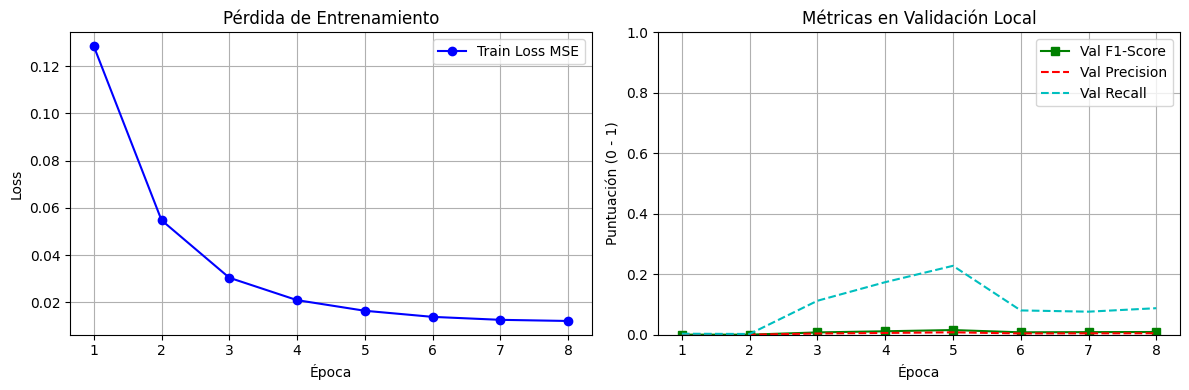

In [29]:
# --- 7. BUCLE DE ENTRENAMIENTO Y MONITORIZACIÓN ---
print(f"⚡ Dispositivo: {DEVICE.upper()}", flush=True)
model = UNet3D().to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# <-- CAMBIO 1: Scheduler para bajar la tasa de aprendizaje suavemente
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

criterion = HeatmapMSELoss()  # Mantenemos HeatmapMSELoss
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

history = {"train_loss": [], "val_f1": [], "val_prec": [], "val_rec": []}

# <-- CAMBIO 2: Variables para guardar el mejor modelo histórico
best_val_f1 = -1.0
best_epoch = -1

start_train_time = time.time()

for epoch in range(EPOCHS):
    # --- A) ENTRENAMIENTO ---
    model.train()
    epoch_loss, total_batches = 0.0, 0

    for z_path, g_path in train_pairs:
        seq_dataset = TrainCellDatasetGEFF(
            zarr_path=z_path,
            geff_path=g_path,
            patch_size=PATCH_SIZE,
            samples_per_epoch=SAMPLES_PER_SEQ,
        )
        seq_dataloader = DataLoader(
            seq_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True
        )

        for x, y in seq_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                out = model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            total_batches += 1

    mean_train_loss = epoch_loss / total_batches
    history["train_loss"].append(mean_train_loss)

    # <-- CAMBIO 1 (cont.): Avanzar el scheduler por época
    scheduler.step()

    # --- B) VALIDACIÓN LOCAL (F1-Score) ---
    print(f"⏳ Evaluando F1 en validación local (Época {epoch + 1})...", flush=True)
    val_f1, val_prec, val_rec = evaluate_validation_f1(model, val_pairs)

    history["val_f1"].append(val_f1)
    history["val_prec"].append(val_prec)
    history["val_rec"].append(val_rec)

    # <-- CAMBIO 2 (cont.): Guardar automáticamente el modelo si supera el mejor F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_unet3d_cell_tracker.pth")
        print(
            f"  ★ ¡Nuevo récord de F1 local ({val_f1:.4f})! Checkpoint guardado en 'best_unet3d_cell_tracker.pth'",
            flush=True,
        )

    print(
        f"Época [{epoch + 1}/{EPOCHS}] - Train Loss HeatmapMSELoss: {mean_train_loss:.6f} | "
        f"Val F1: {val_f1:.4f} (Prec: {val_prec:.4f}, Rec: {val_rec:.4f}) | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}",
        flush=True,
    )

print(
    f"⏱️ Entrenamiento finalizado en: {(time.time() - start_train_time) / 60:.2f} min.",
    flush=True,
)
print(
    f"🏆 Mejor Época guardada: Época {best_epoch} con F1: {best_val_f1:.4f}",
    flush=True,
)

# <-- CAMBIO 3: Cargar los mejores pesos guardados para la inferencia posterior
model.load_state_dict(torch.load("best_unet3d_cell_tracker.pth"))
print("✅ Cargados los pesos de la mejor época para uso posterior.", flush=True)

# --- GRAFICAR RESULTADOS DE VALIDACIÓN ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train Loss MSE")
ax1.set_title("Pérdida de Entrenamiento")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend()

ax2.plot(epochs_range, history["val_f1"], "g-s", label="Val F1-Score")
ax2.plot(epochs_range, history["val_prec"], "r--", label="Val Precision")
ax2.plot(epochs_range, history["val_rec"], "c--", label="Val Recall")
ax2.set_title("Métricas en Validación Local")
ax2.set_xlabel("Época")
ax2.set_ylabel("Puntuación (0 - 1)")
ax2.set_ylim(0, 1.0)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [27]:
model.load_state_dict(torch.load("best_unet3d_cell_tracker.pth"))
val_f1, val_prec, val_rec = evaluate_validation_f1(model, val_pairs)

print(f"📊 Re-evaluación con umbral adaptativo:")
print(f"Val F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}")

📊 Re-evaluación con umbral adaptativo:
Val F1: 0.0144 | Prec: 0.0075 | Rec: 0.2148


## Bloque 5: Bucle de inferencia en Test set y generación de submission.csv

In [8]:
# --- 8. BUCLE DE INFERENCIA Y SUBMISSION EN TEST SET ---
test_zarr_paths = sorted(list(TEST_DIR.glob("*.zarr")))
print(
    f"🚀 Procesando {len(test_zarr_paths)} secuencias de test para submission...",
    flush=True,
)

start_infer_time = time.time()

with open(OUTPUT_SUBMISSION_PATH, mode="w", newline="") as f:
    writer = csv.writer(f)

    header = [
        "id",
        "dataset",
        "row_type",
        "node_id",
        "t",
        "z",
        "y",
        "x",
        "source_id",
        "target_id",
    ]
    writer.writerow(header)

    global_row_id = 0

    for zarr_path in test_zarr_paths:
        t_start_seq = time.time()
        dataset_name = zarr_path.name.replace(".zarr", "")

        zarr_group = zarr.open(zarr_path, mode="r")["0"]
        full_sequence = zarr_group[:]

        num_timesteps = full_sequence.shape[0]

        global_node_id = 1
        prev_ids, prev_coords = [], np.empty((0, 3), dtype=np.float32)

        seq_nodes_rows = []
        seq_edges_rows = []
        valid_node_ids = set()

        for t in range(num_timesteps):
            vol_t = full_sequence[t]
            centroids = extract_centroids_physical(model, vol_t, thresh=0.35)

            curr_ids, curr_coords_list = [], []

            for z, y, x in centroids:
                node_id_val = int(global_node_id)
                seq_nodes_rows.append([
                    dataset_name,
                    "node",
                    node_id_val,
                    int(t),
                    int(z),
                    int(y),
                    int(x),
                    -1,
                    -1,
                ])
                valid_node_ids.add(node_id_val)
                curr_ids.append(node_id_val)
                curr_coords_list.append([z, y, x])
                global_node_id += 1

            curr_coords = (
                np.array(curr_coords_list, dtype=np.float32)
                if len(curr_coords_list) > 0
                else np.empty((0, 3), dtype=np.float32)
            )

            if len(prev_ids) > 0 and len(curr_ids) > 0:
                dist_matrix = cdist(prev_coords, curr_coords)
                row_ind, col_ind = linear_sum_assignment(dist_matrix)

                for r, c in zip(row_ind, col_ind):
                    if dist_matrix[r, c] <= MAX_DISTANCE_VOXELS:
                        src_id = int(prev_ids[r])
                        tgt_id = int(curr_ids[c])
                        if (
                            src_id in valid_node_ids
                            and tgt_id in valid_node_ids
                        ):
                            seq_edges_rows.append([
                                dataset_name,
                                "edge",
                                -1,
                                -1,
                                -1,
                                -1,
                                -1,
                                src_id,
                                tgt_id,
                            ])

            prev_ids, prev_coords = curr_ids, curr_coords

        if len(seq_nodes_rows) == 0:
            z_m, y_m, x_m = full_sequence.shape[1:]
            seq_nodes_rows.append([
                dataset_name,
                "node",
                1,
                0,
                int(z_m // 2),
                int(y_m // 2),
                int(x_m // 2),
                -1,
                -1,
            ])

        for row in seq_nodes_rows:
            writer.writerow([global_row_id] + row)
            global_row_id += 1

        for row in seq_edges_rows:
            writer.writerow([global_row_id] + row)
            global_row_id += 1

        print(
            f"  └─ {dataset_name} completado en {time.time() - t_start_seq:.2f}s",
            flush=True,
        )

        del full_sequence, seq_nodes_rows, seq_edges_rows, valid_node_ids
        gc.collect()

print(
    f"\n✨ Inferencia completada con éxito en {(time.time() - start_infer_time) / 60:.2f} minutos. Filas totales: {global_row_id}",
    flush=True,
)

🚀 Procesando 4 secuencias de test para submission...
  └─ 44b6_0113de3b completado en 38.76s
  └─ 44b6_0b24845f completado en 38.52s
  └─ 6bba_05b6850b completado en 38.01s
  └─ 6bba_05db0fb1 completado en 40.25s

✨ Inferencia completada con éxito en 2.60 minutos. Filas totales: 16231
